# Assignment 2: Reproducing figures from OASIS Open Agent Social Interaction Simulations with One Million Agents Paper

For the second assignment our task is to replicate Figure 4 to 6 with the results of 10 Agents based on the OASIS Paper. 
The phenomen studied in the paper is Agent based model simulations on real scenarios: Twitter/Reddit with LLMs to understand how to use agent based models on real scenarios of social media platforms. 

The paper is by Yang et al., 2024.
https://arxiv.org/abs/2411.11581 
https://doi.org/10.48550/arXiv.2411.11581 

Furthermore did we work with the reddit dataset of the github server of Yang et al., 2024. We reproduced the social phenomenas of polarization and herd effect in a simplified manner on a small scale using mesa simulation modelling. Used mesa model is 3.3.1.

https://github.com/camel-ai/oasis. 




<img src ='OASIS.png'>

## Workflow and internal mechanisms of OASIS

OASIS is a LLM based simulator for various social media applications. It is built upon the structure of traditional social media platforms and consists of 5 key components: Environment Server, RecSy, Agent Module, Time Engine and Scalable Inferencer (Yang et al., 2024). The phases in which the model functions is split into regristration phase and simulation phase.

### Regristration Phase
During this phase OASIS registers each user (agent),with user information, including name, self description and historical posts furthermore does the agent receives a character and action description so actions align with it. 

### Simulation Phase
In the Simulation Phase the enviroments sends user related information like past behaviour and self description to the Recommender System which then filters post from the environment and suggests post that are likely to be interesting to the agent. Based on the posts and description the agent takes actions like e.g. reposting. Chain_of_thought reasoning helps in understanding the models behaviour. 

### Environment Server
The environment server maintains the status and data of the platforms such as user info, user relationsships,posts, comments,recommendations and other action related traces which are stored in different tables. The recommendation table is populated by outputs from the Recommender System after the analysis of the users trace table. 

### RecSys
The recommender system controls the information seen by agent which is aligned with either X or the Reddit recommender system. The sources of post come from the in network, the agents followed directly by the user and the out of network, post from the broader 'world' simulation. In network content is recommended ranked by popularity of e.g. likes and the out of network posts are being recommended based on the interest matches of the agent measured by interest vectors similarity. Factors such as priorising recent post and number of followers of the posting user are also taken into consideration (influencer).
--> Depending on which Social Media we use we can add information about the algorithm of recsystem

### Agent Module 
The agent module is based on LLM with corefeatures of agent module inherited from CAMEL (Li et al., 2023).The agent module consists of memory modula and action module. The memory stores the information encountered to help the agent understand its role when performing actions. The action module enables different types of interactions such as, sign up, refresh,searching users/posts, create, repost follow and many more associated functions of traditional social media plattforms. CoT reasoning is used for the better interpretability of the agents behaviour. 

### Time Engine
Time engine incorperates temporal features that reflect the real world online behaviour patterns, such as hourly activity level based on historical interactions. Each agent has a 24 dimensional vector that represents the probability of activity in each hour which then activates the user based on the probabilities. 

### Scalable Inference
The design of the distribution system is highly scalabale. The agents, environments and inference server operate independently and exchange data through information communication channels. This allos the agents to send multiple requests at the same time while waiting for resposnes of previous interactions, simulating real world behaviour. 

### Large Scale User Generation 
The user generation algorithms combines real user data with a relationship network, which enables to simulation of up to 1 million users which still having a scale-free network. The algorithm generates diverse user profiles based on population distributions with interest based sampling of core and ordinary users with a probability of 0.2.


For our Model we have created a simplified Version with Mesa Agent based modelling.


<img src ='Workflow.png'>

## Experiment 1
The paper showcases how interaction with the same opinion might cause a polarization within the community and the users. We are trying to reproduce this behvaiour on a small scale with 10 agents to showcase this. All agents start with a cautious starting position on a shared discussion topic after repeated interaction with posts some agents move towards more polarized opinion. We compare the opinions at different starting points to the beginning round 0.  

In [216]:
%pip install mesa[rec]
%pip install seaborn
%pip install camel-oasis #installing OASIS package

zsh:1: no matches found: mesa[rec]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [217]:
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os 
import sys
import json
import sqlite3
from pathlib import Path 
from IPython.display import JSON, display





In [218]:
#using the reddit data set from Oasis paper
Datapath = Path("/Users/janniella/Desktop/SoSE26/Computational Modelling/OASIS/data/reddit/user_data_36.json")

with open (Datapath, "r") as file:
    userdata = json.load(file)
len(userdata)

users10 = userdata[:10] #selecting 10 users from the dataset



display(JSON(users10)) #checking whether it opened 10 userdatas correctly
with open ("users10output.json","w") as file:
    json.dump(users10,file,indent=2, ensure_ascii=False)
#creating a json file with the information of the users that will later be used for the probability of the users

<IPython.core.display.JSON object>

In [219]:
#creating the agents from the users

class Reddit_Useragent(mesa.Agent):
    def __init__(self,model,profile,firstopinion,community,pronetoopinions,confirmationbias,activity):
        super ().__init__(model)

        #data from the oasis model
        self.username = profile["username"]
        self.bio = profile["bio"]
        self.persona = profile["persona"]
        self.age = profile["age"]
        self.gender = profile["gender"]
        self.country = profile["country"]
        self.interested_topics = profile["interested_topics"]
        self.mbti = profile["mbti"]
        self.profession = profile["profession"]

        #properties important for the simulation 
        self.opinion = firstopinion
        self.community = community
        self.pronetoopinions = pronetoopinions #how easily the agent changes opinion
        self.confirmationbias = confirmationbias # how strongly the agent favors agreeing
        self.activity = activity 

    
    # it the post is close to the opinion of the user it moves towards it else it moves away from it if it differs from opinion
    def react_to_post(self,post):
        opiniongap = abs(self.opinion - post.stanceofpost)
        if opiniongap < 0.5:
            change = post.stanceofpost - self.opinion
            multiplier = 0.12

        else: 
            change = self.opinion - post.stanceofpost
            multiplier = -0.08

        
        bias_multiplier = 1 + self.confirmationbias
        self.opinion += self.pronetoopinions *multiplier*bias_multiplier *change
        self.opinion = float(np.clip(self.opinion, -1,1))
        
        #if the agent and post have the same direction it gets a upvote else downvote like in reddit
        if self.opinion * post.stanceofpost >= 0:
            post.upvotes +=1
        else:
            post.downvotes += 1

    
    def createpostfromopinion(self):
        
        return{
            "community": self.community, 
            "stanceofpost": self.opinion, 
            "topics": self.interested_topics
        }

### Simulate the probability of behaviour by looking at persona, topics of interest and MBTI information given my the dataset

The dataset of Oasis gives information such as MBTI and topics of interest as well as vague stance with words such as "passionate", "research". These are used in our model to approximate the probability of a certain behaviour the agent will elicit. 


The MBTI is also taken into account as the Letters in it gives insight on how likely a person is acting in sensing vs intuition and feeling vs thinking as well as extroversion vs introvertion (that could be useful for herd effect probability).

<img src ='MBTI.png'>
Example of how common each statistic is.

source: https://crowncounseling.com/statistics/myers-briggs/ 

In [220]:
# to create a probability for the probability of suceptability to opinions 
# we use the information given by the persona to vaguely create direction 
# for this we looked at the output given by the 10 agents created and analyzed the keywords in their bio,profession and interested topics
#probabilities are being clipped to 0 and 1 
def clippingprobability (value):
    return min(max(value, 0.0),1.0)


def traitsfrompersona (profile):
    persona = profile["persona"].lower()
    bio = profile ["bio"].lower()
    topics = " ".join(profile["interested_topics"]).lower()
    mbti = profile["mbti"].upper() 

    text = persona + "" + bio + "" + topics

    #baselinevalues
    pronetoopinions = 0.5
    confirmationbias = 0.5
    activity = 0.85
    
    # persona based probability
    #these words suggest that the person is likely to be active and strongminded in their opinion
    if any(word in text for word in [
        "passionate", "enthusiast","advocate","dedicated","driven"
    ]):
           activity += 0.08
           confirmationbias +=0.06

    #these traits suggest that the agent is likely analytical and logical,therefore possibly less suceptible to opinions based on emotions
    if any(word in text for word in [
        "analytical", "analyzing","market trends","logical","methodical","detail-oriented","financial data"
    ]):
           pronetoopinions -= 0.08
           confirmationbias +=0.05

    #these words tend to present a person who is open minded to different opinions
    if any(word in text for word in [
        "curious", "exploring","learning","seeking knowledge","exchange ideas"
    ]):
           pronetoopinions += 0.08

    #tends to present a user who is active in discussions    
    if any(word in text for word in [
        "community","connecting","discussing","sharing insights","exchange ideas","social issues"
    ]):
           activity += 0.08

    # more agreeable kind person 
    if any(word in text for word in [
        "helping others","positive impact","greater good","compassionate","empathetic","social welfare"
    ]):
           pronetoopinions += 0.05
           confirmationbias -= 0.05

    

    # MBTI based probabilities E extroverted, I introverted, N intuition, S sensing, T thinking, F feeling, J judging , P perceiving
    if "E" in mbti: 
        activity += 0.10
    if "I" in mbti: 
        activity -= 0.05

    if "N" in mbti: 
        pronetoopinions += 0.05
    if "S" in mbti: 
        confirmationbias += 0.05

    if "T" in mbti: 
        pronetoopinions -= 0.05
    if "F" in mbti: 
        pronetoopinions += 0.05
    
    if "J" in mbti: 
        confirmationbias += 0.05
    if "P" in mbti: 
        confirmationbias -= 0.05

    return {
        "pronetoopinions": clippingprobability(pronetoopinions), 
        "confirmationbias": clippingprobability(confirmationbias),
        "activity": clippingprobability(activity),
    }




In [221]:
for profile in users10:
    traits = traitsfrompersona(profile)
    print(
        profile["username"],
        profile["mbti"],
        traits
    )

millerhospitality ESTJ {'pronetoopinions': 0.45, 'confirmationbias': 0.7100000000000002, 'activity': 1.0}
emma_logistics_guru ENFJ {'pronetoopinions': 0.68, 'confirmationbias': 0.6100000000000001, 'activity': 1.0}
ryantechsavvy22 ENTJ {'pronetoopinions': 0.58, 'confirmationbias': 0.6100000000000001, 'activity': 1.0}
biz_mind45 ESTJ {'pronetoopinions': 0.37, 'confirmationbias': 0.7100000000000002, 'activity': 1.0}
JakeAgEcon ISTJ {'pronetoopinions': 0.45, 'confirmationbias': 0.7100000000000002, 'activity': 0.8799999999999999}
EcoBizExplorer ISFJ {'pronetoopinions': 0.63, 'confirmationbias': 0.6600000000000001, 'activity': 0.96}
intj_emily INTJ {'pronetoopinions': 0.5, 'confirmationbias': 0.6000000000000001, 'activity': 0.7999999999999999}
sereneadvocate ISFJ {'pronetoopinions': 0.68, 'confirmationbias': 0.6100000000000001, 'activity': 0.96}
hfarmer47 ISFJ {'pronetoopinions': 0.63, 'confirmationbias': 0.6600000000000001, 'activity': 0.8799999999999999}
ethan_the_infp INFP {'pronetoopinio

In [222]:
#based on the topics of interested the agents are being put toward one community side
def communityfromprofile(profile):
    return "discussion"

In [223]:
def firstopinion (profile):
    
    persona = profile["persona"].lower()
    bio = profile ["bio"].lower()
    topics = " ".join(profile["interested_topics"]).lower()
    profession = profile["profession"].lower() 

    text = persona + "" + bio + "" + topics + "" + profession

    #as in the paper every agent starts midly cautious/conservative
    base = -0.20
    opinionshift = 0.0
    #based on the keywords found in the text it pushes into a direction of being analytical and sceptical - or leaning towards agreeableness 
    if any(word in text for word in [
        "analytical", "careful","methodical", "research"
    ]):
        opinionshift -= 0.05
    
    if any(word in text for word in [
        "creative", "ambitious", "innovative", "driven"
    ]):
        opinionshift += 0.05


    noise = np.random.uniform(-0.05,0.05) #bit of noise flavour
    return float (np.clip(base + opinionshift +noise, -1,1))
    

In [224]:
# Posting class that simulates the social media way of activity
#stance of post showcases the opion of the post it can be  -1 strongly against topic, 0 neutral or +1 in favour of topic
# community is in which community the post appears
#createdstep shows the time step for when the post was created

class RedditPost: 
    def __init__(self,postid, authorid, community, stanceofpost, createdstep,topics):
        self.postid = postid
        self.authorid = authorid
        self.community = community
        self.stanceofpost= stanceofpost
        self.createdstep = createdstep
        self.topics = topics
        self.upvotes = 0
        self.downvotes = 0 

    @property
    def score(self):
        return self.upvotes - self.downvotes #popularity
    


In [225]:
# Model

class Reddit (mesa.Model):
    def __init__ (self, users, seed = 42):
        super().__init__ (seed = seed)

        self.currentstep = 0
        self.posts = []
        self.nextpostid = 1
        self.agentlist = []
        
        
        for profile in users: 
            traits = traitsfrompersona(profile)

            agent = Reddit_Useragent (
                model=self, 
                profile = profile, 
                firstopinion= firstopinion(profile),
                community = communityfromprofile(profile),
                pronetoopinions= traits ["pronetoopinions"],
                confirmationbias = traits["confirmationbias"],
                activity = traits["activity"]
            )

            self.agentlist.append(agent)


# the interests of the agents are taken into account
    def add_post(self, authorid,community,stanceofpost,topics):
        post = RedditPost (
            postid = self.nextpostid,
            authorid= authorid, 
            community= community,
            stanceofpost= stanceofpost, 
            createdstep= self.currentstep, 
            topics = topics,
        )

        self.posts.append(post)
        self.nextpostid +=1


#recommender system that recommends posts based on the match to own interest
    def recommendpost (self, agent, feed_size = 5):
        ranked_posts=[]

        for post in self.posts: 
            opinion_similarity = 1 -abs(agent.opinion - post.stanceofpost)/2 #closeness to agent opinion
            score_effect =np.tanh(post.score / 5) #popularity
            age = self.currentstep - post.createdstep #newer post higher rank
            recency = 1/ (1+age)
            interest_effect = interest_similarity(agent, post)
            


            rank = (
                0.6 * score_effect
                +0.4 *opinion_similarity
                +0.5 * interest_effect
                +0.7 * recency
            )

            ranked_posts.append((rank, post))

        ranked_posts.sort(key=lambda x: x[0], reverse = True)
        return [post for rank, post in ranked_posts[:feed_size]]
    
    
    #acitivity of agents
    def step(self):
            self.currentstep += 1
            for agent in self.agentlist: 
                if random.random() < agent.activity: 
                    feed = self.recommendpost(agent,feed_size=5) #recommended posts

                    for post in feed: 
                        agent.react_to_post(post)

                    if random.random()< 0.3: #probability of 0.3 that agent will create a new post
                        new_post = agent.createpostfromopinion()
                        self.add_post(
                            authorid= agent.unique_id,
                            community=new_post["community"],
                            stanceofpost= new_post["stanceofpost"],
                            topics= new_post["topics"]

                        )

In [226]:
model = Reddit (users10)
for agent in model.agentlist: 
    print(
        agent.username, 
        agent.mbti,
        agent.community, 
        round(agent.opinion, 2),
        round(agent.pronetoopinions,2),
        round(agent.confirmationbias,2),
        round(agent.activity,2),
    )

millerhospitality ESTJ discussion -0.16 0.45 0.71 1.0
emma_logistics_guru ENFJ discussion -0.2 0.68 0.61 1.0
ryantechsavvy22 ENTJ discussion -0.14 0.58 0.61 1.0
biz_mind45 ESTJ discussion -0.11 0.37 0.71 1.0
JakeAgEcon ISTJ discussion -0.24 0.45 0.71 0.88
EcoBizExplorer ISFJ discussion -0.23 0.63 0.66 0.96
intj_emily INTJ discussion -0.25 0.5 0.6 0.8
sereneadvocate ISFJ discussion -0.18 0.68 0.61 0.96
hfarmer47 ISFJ discussion -0.16 0.63 0.66 0.88
ethan_the_infp INFP discussion -0.12 0.68 0.51 0.88


In [227]:
# recommender system that looks whether interests are similar

def interest_similarity (agent, post):
    agent_topics = set(agent.interested_topics)
    post_topics = set(post.topics)

    overlap = len(agent_topics.intersection(post_topics))
    total = len (agent_topics.union(post_topics))

    if total == 0:
        return 0.0
    
    return overlap/total 

In [228]:
# running the simulation 

def run_simulation (model, n_steps = 30):
    opinionhistory = []
    scorehistory = []

    for step in range (n_steps +1):
        print("running step", step)
        opinionhistory.append(
            [agent.opinion for agent in model.agentlist]
        )

        scorehistory.append(
            [post.score for post in model.posts]
        )

        if step < n_steps:
            model.step()

    return np.array(opinionhistory), scorehistory

In [ ]:
model = Reddit(users10)

for i in range(3):
    model.add_post(
        authorid = i+1, 
        community = "discussion",
        stanceofpost =- 0.15 + np.random.uniform(-0.05,0.05),
        topics = ["Politics","Career","Risk"]
    )

opinionhistory, scorehistory = run_simulation(model, n_steps=30)

running step 0
running step 1
running step 2
running step 3
running step 4
running step 5
running step 6
running step 7
running step 8
running step 9
running step 10
running step 11
running step 12
running step 13
running step 14
running step 15
running step 16
running step 17
running step 18
running step 19
running step 20
running step 21
running step 22
running step 23
running step 24
running step 25
running step 26
running step 27
running step 28
running step 29
running step 30


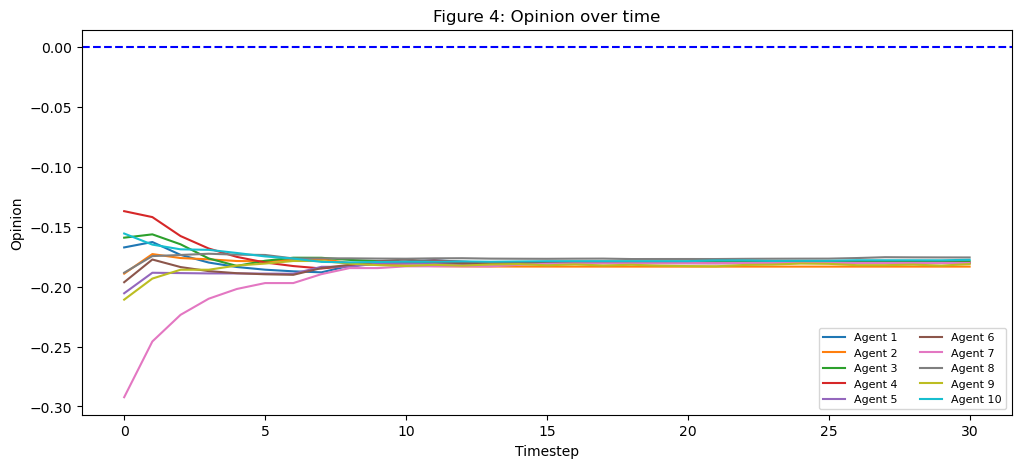

In [230]:
#Plotting Figure 4

plt.figure (figsize= (12,5))

for i in range (opinionhistory.shape[1]):
    plt.plot(opinionhistory[:,i],label =f"Agent {i+1}")

plt.axhline(0,color= "blue", linestyle= "--")
plt.title("Figure 4: Opinion over time")
plt.xlabel ("Timestep")
plt.ylabel("Opinion")
plt.legend(ncol = 2, fontsize = 8)
plt.show()

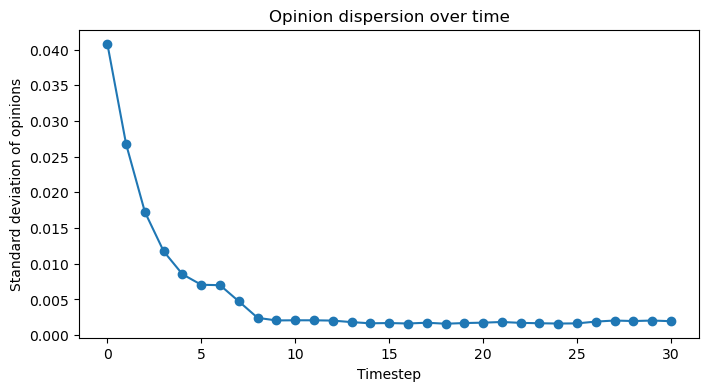

In [231]:
polarizationstrength = np.std(opinionhistory, axis= 1)

plt.figure(figsize=(8,4))
plt.plot(polarizationstrength, marker = "o")
plt.title("Opinion dispersion over time")
plt.xlabel("Timestep")
plt.ylabel("Standard deviation of opinions")
plt.show()

In [232]:
def comparetoround0 (opinionhistory, tolerance= 0.02):
    baseline = opinionhistory[0]
    results = []

    for t in range (opinionhistory.shape[0]):
        current = opinionhistory[t]

        more_extreme = np.sum(np.abs(current) > np.abs(baseline) +tolerance)
        less_extreme = np.sum(np.abs(current) < np.abs(baseline) - tolerance)
        draw = np.sum(np.abs(np.abs(current) - np.abs(baseline)) <= tolerance)

        results.append({
            "timestep" : t, 
            "more_extreme": more_extreme,
            "less_extreme": less_extreme,
            "draw": draw
        })

    return pd.DataFrame(results)

In [233]:
figure5_df = comparetoround0(opinionhistory)
figure5_df

print (figure5_df.columns)

Index(['timestep', 'more_extreme', 'less_extreme', 'draw'], dtype='object')


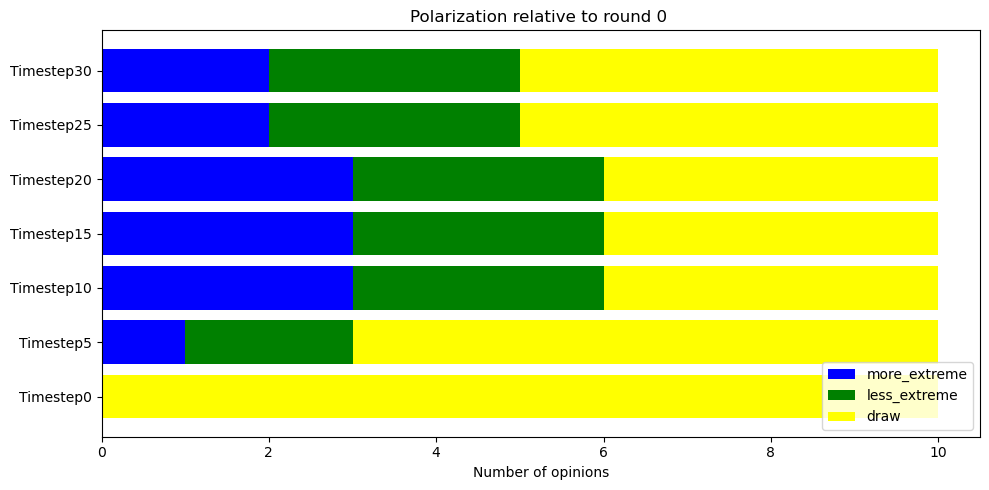

In [ ]:

selectedtimesteps = [0,5,10,15,20,25,30]
plotdf = figure5_df[figure5_df["timestep"].isin(selectedtimesteps)]


plt.figure(figsize=(10,5))

ylabels= [f"Timestep{t}" for t in plotdf["timestep"]]

plt.barh(
    ylabels, 
    plotdf["more_extreme"],
    color = "blue", 
    label= "more_extreme"
)

plt.barh(
    ylabels, 
    plotdf["less_extreme"],
    left=plotdf["more_extreme"],
    color = "green", 
    label= "less_extreme"
)

plt.barh(
    ylabels, 
    plotdf["draw"],
    left=plotdf["more_extreme"]+ plotdf["less_extreme"],
    color = "yellow", 
    label= "no clear change"
)

plt.xlabel("Number of opinions")
plt.title ("Polarization relative to round 0 ")
plt.legend(loc= "lower right")
plt.tight_layout()
plt.show()

Figure 5 shows that the agents tend to behave in different manners, either they adapt to a more extreme opinion or they become less extreme a big majority also has no changes from the round 0 starting opinion stand point. 